In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [2]:
nasc_estado = pd.read_csv(
    'quedas nascimento por estado.csv',
    sep=';',
    skiprows=3,
    encoding='latin1'
)

nasc_estado = nasc_estado.dropna(how='all')

print(nasc_estado.head())
print(nasc_estado.columns.tolist())

  Região/Unidade da Federação      2010      2011      2012      2013  \
0                Região Norte  306422.0  313745.0  308375.0  313272.0   
1                 .. Rondônia   25835.0   27658.0   26513.0   27097.0   
2                     .. Acre   16495.0   17817.0   16700.0   17075.0   
3                 .. Amazonas   74188.0   76202.0   77434.0   79041.0   
4                  .. Roraima    9738.0    9945.0   10601.0   10814.0   

       2014      2015      2016      2017      2018      2019      2020  \
0  321682.0  320924.0  307526.0  312682.0  319228.0  313696.0  301635.0   
1   27560.0   27918.0   26602.0   27503.0   28091.0   27028.0   25798.0   
2   17139.0   16980.0   15773.0   16358.0   16543.0   16280.0   15142.0   
3   81145.0   80097.0   76703.0   78066.0   78087.0   77622.0   75635.0   
4   11120.0   11412.0   11376.0   11737.0   13344.0   14620.0   13760.0   

       2021      2022      2023      2024      Total  
0  309362.0  289158.0  284197.0  265670.0  4587574.0  


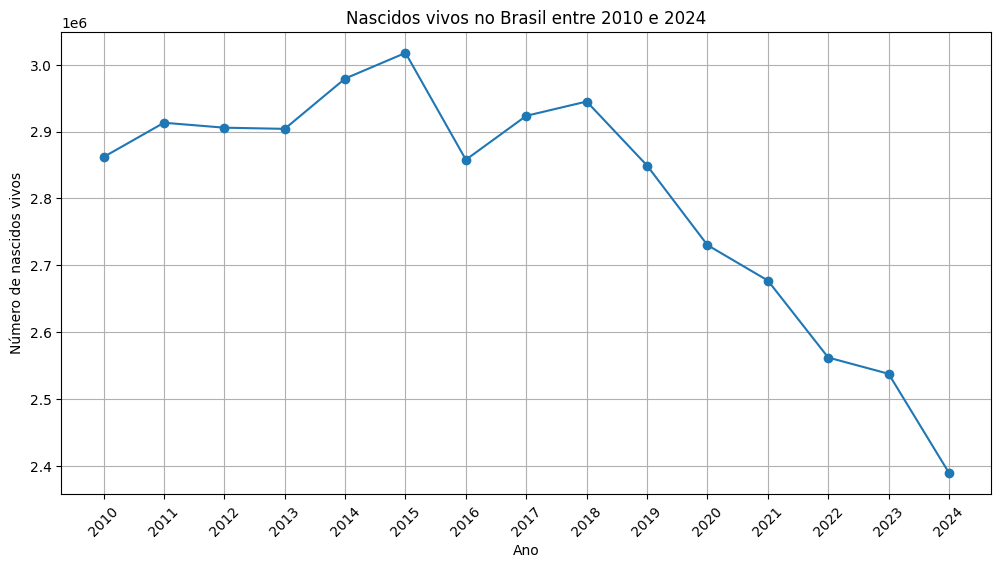

In [3]:
anos_brasil = [str(ano) for ano in range(2010, 2025)]

coluna_estado = nasc_estado.columns[0]

total_brasil = nasc_estado[nasc_estado[coluna_estado] == 'Total']

valores = total_brasil[anos_brasil].iloc[0]

plt.figure(figsize=(12, 6))
plt.plot(anos_brasil, valores, marker='o')
plt.title('Nascidos vivos no Brasil entre 2010 e 2024')
plt.xlabel('Ano')
plt.ylabel('Número de nascidos vivos')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

In [4]:
estados = nasc_estado[
    nasc_estado[coluna_estado].astype(str).str.startswith('..')
].copy()

estados[coluna_estado] = estados[coluna_estado].str.replace('.. ', '', regex=False)

estados['Queda_%'] = ((estados['2024'] - estados['2010']) / estados['2010']) * 100

ranking_queda = estados[[coluna_estado, '2010', '2024', 'Queda_%']]
ranking_queda = ranking_queda.sort_values('Queda_%')

print(ranking_queda)

   Região/Unidade da Federação      2010      2024    Queda_%
31            Distrito Federal   44251.0   33282.0 -24.788140
17                       Bahia  212201.0  160002.0 -24.598847
21              Rio de Janeiro  215262.0  163722.0 -23.942916
12         Rio Grande do Norte   47668.0   36612.0 -23.193757
9                     Maranhão  119566.0   92173.0 -22.910359
22                   São Paulo  601352.0  470887.0 -21.695280
2                         Acre   16495.0   13101.0 -20.575932
10                       Piauí   49424.0   39697.0 -19.680722
16                     Sergipe   34016.0   27545.0 -19.023401
14                  Pernambuco  136591.0  110827.0 -18.862151
11                       Ceará  128831.0  105453.0 -18.146254
6                        Amapá   15008.0   12327.0 -17.863806
15                     Alagoas   54164.0   45436.0 -16.114024
26           Rio Grande do Sul  133243.0  111988.0 -15.952058
1                     Rondônia   25835.0   21716.0 -15.943488
13      

In [5]:
X = estados[anos_brasil]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [6]:
silhuetas = []

for k in range(2, 7):
    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    grupos = modelo.fit_predict(X_scaled)

    valor_silhueta = silhouette_score(X_scaled, grupos)

    silhuetas.append(valor_silhueta)

print(silhuetas)

c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Window

[0.8113861836472505, 0.6181768677208629, 0.6512782881769605, 0.574696047844369, 0.5819932060304844]


c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


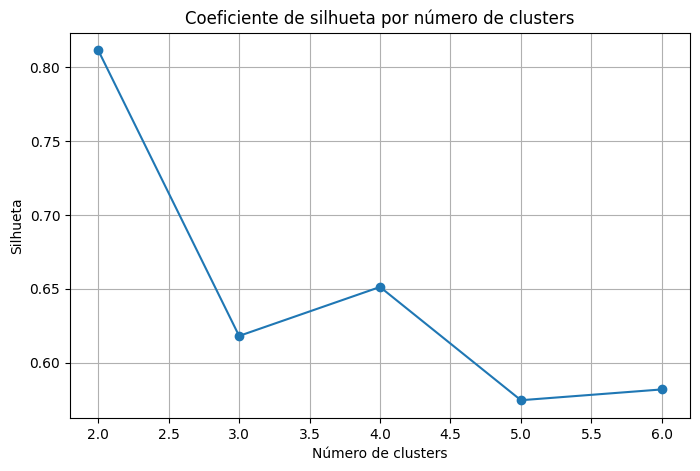

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(2, 7), silhuetas, marker='o')
plt.title('Coeficiente de silhueta por número de clusters')
plt.xlabel('Número de clusters')
plt.ylabel('Silhueta')
plt.grid(True)
plt.show()

In [8]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)

estados['Cluster'] = kmeans.fit_predict(X_scaled)

resultado_cluster = estados[
    [coluna_estado, '2010', '2024', 'Queda_%', 'Cluster']
].sort_values('Cluster')

print(resultado_cluster)

   Região/Unidade da Federação      2010      2024    Queda_%  Cluster
1                     Rondônia   25835.0   21716.0 -15.943488        0
29                 Mato Grosso   48929.0   55310.0  13.041346        0
28          Mato Grosso do Sul   40132.0   37908.0  -5.541712        0
26           Rio Grande do Sul  133243.0  111988.0 -15.952058        0
25              Santa Catarina   84611.0   93787.0  10.844926        0
24                      Paraná  152051.0  131027.0 -13.826940        0
21              Rio de Janeiro  215262.0  163722.0 -23.942916        0
20              Espírito Santo   51853.0   49937.0  -3.695061        0
19                Minas Gerais  255126.0  219819.0 -13.839044        0
17                       Bahia  212201.0  160002.0 -24.598847        0
16                     Sergipe   34016.0   27545.0 -19.023401        0
30                       Goiás   87476.0   88867.0   1.590150        0
15                     Alagoas   54164.0   45436.0 -16.114024        0
13    

c:\Users\natal\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


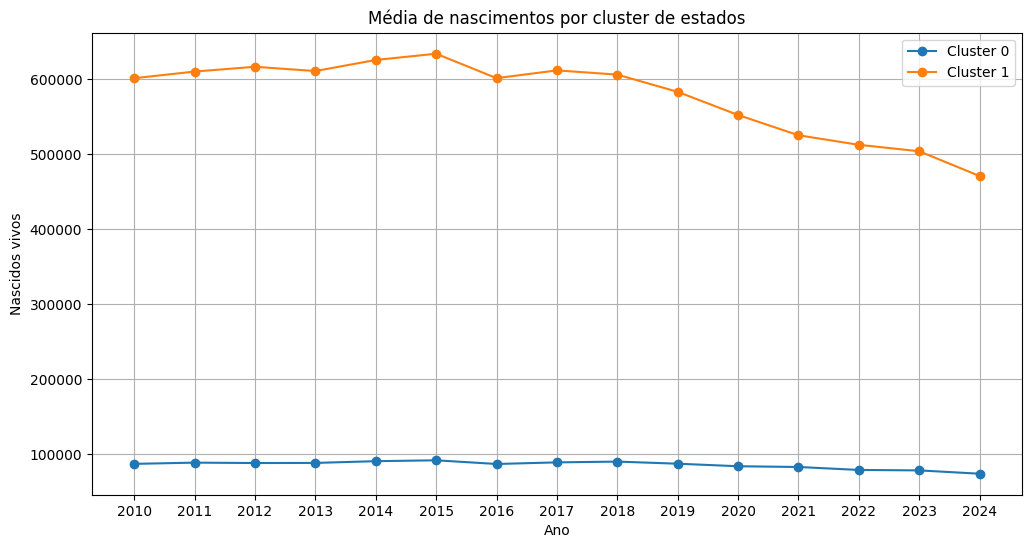

In [9]:
media_clusters = estados.groupby('Cluster')[anos_brasil].mean()

plt.figure(figsize=(12, 6))

for cluster in media_clusters.index:
    plt.plot(
        anos_brasil,
        media_clusters.loc[cluster],
        marker='o',
        label=f'Cluster {cluster}'
    )

plt.title('Média de nascimentos por cluster de estados')
plt.xlabel('Ano')
plt.ylabel('Nascidos vivos')
plt.legend()
plt.grid(True)
plt.show()

In [10]:
ranking = resultado_cluster.sort_values(
    by='Queda_%',
    ascending=True
)

ranking.to_csv('ranking_queda_estados.csv', index=False)
resultado_cluster.to_csv('clusters_estados.csv', index=False)

print('Arquivos salvos com sucesso.')

Arquivos salvos com sucesso.
